# Session 10 — Logistic Regression, Sigmoid Function & Decision Thresholds
---

### Theoretical Overview:
1. **Classification vs Regression**:
   - In linear regression, the output $\hat{y} = w^T x + b$ can range anywhere in $(-\infty, +\infty)$, which is unsuitable for binary classification where outcomes are probabilities $P(y=1) \in [0, 1]$.
   - **Logistic Regression** solves this by passing the linear combination (the **log-odds** or **logit**) through an activation function known as the **Sigmoid (Logistic) Function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

2. **Properties of Sigmoid**:
   - Maps any real number $z \in (-\infty, +\infty)$ strictly to the open interval $(0, 1)$.
   - At $z = 0$, $\sigma(0) = 0.5$.
   - As $z \to +\infty$, $\sigma(z) \to 1$.
   - As $z \to -\infty$, $\sigma(z) \to 0$.
   - Monotonically increasing and strictly differentiable: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.

3. **Decision Thresholds**:
   - The output of the sigmoid function represents the conditional probability $P(Y=1|X)$.
   - To make a hard binary prediction $\hat{y} \in \{0, 1\}$, a **decision threshold** $\tau$ is applied:
     $$\hat{y} = \begin{cases} 1 & \text{if } P(Y=1|X) \ge \tau \\ 0 & \text{if } P(Y=1|X) < \tau \end{cases}$$
   - While $0.5$ is standard, tuning $\tau$ allows balancing **precision** vs **recall** depending on the business context.


## Question 1
**Create a Python function `sigmoid(x)` that takes a numeric input and returns the sigmoid value using the formula $\frac{1}{1 + \exp(-x)}$. Test your function with $x = -2$, $0$, and $3$.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

def sigmoid(x):
    '''
    Compute the sigmoid activation for a numeric scalar or numpy array.
    Formula: sigma(x) = 1 / (1 + exp(-x))
    
    Parameters:
        x (float, int, or np.ndarray): Input value(s)
        
    Returns:
        float or np.ndarray: Sigmoid value mapped to (0, 1)
    '''
    return 1.0 / (1.0 + np.exp(-x))

# Test points specified in Question 1
test_inputs = [-2, 0, 3]
results = []

print("=" * 60)
print("TESTING SIGMOID FUNCTION FOR x in [-2, 0, 3]")
print("=" * 60)

for val in test_inputs:
    sig_val = sigmoid(val)
    results.append({
        'Input (x)': val,
        'Formula Computation': f"1 / (1 + exp(-({val})))",
        'Sigmoid Output': round(sig_val, 6),
        'Percentage': f"{sig_val * 100:.2f}%"
    })
    print(f"x = {val:>2}  -->  sigmoid({val:>2}) = {sig_val:.6f}  ({sig_val*100:.2f}%)")

df_sig_test = pd.DataFrame(results)
print("-" * 60)
print(df_sig_test.to_string(index=False))


TESTING SIGMOID FUNCTION FOR x in [-2, 0, 3]
x = -2  -->  sigmoid(-2) = 0.119203  (11.92%)
x =  0  -->  sigmoid( 0) = 0.500000  (50.00%)
x =  3  -->  sigmoid( 3) = 0.952574  (95.26%)
------------------------------------------------------------
 Input (x)  Formula Computation  Sigmoid Output Percentage
        -2 1 / (1 + exp(-(-2)))        0.119203     11.92%
         0  1 / (1 + exp(-(0)))        0.500000     50.00%
         3  1 / (1 + exp(-(3)))        0.952574     95.26%


### Mathematical Analysis of the Test Results:
1. **$x = -2$**:
   - $\sigma(-2) = \frac{1}{1 + e^2} \approx \frac{1}{1 + 7.389} = 0.119203$ ($11.92\%$).
   - Because $x < 0$, the probability is well below the default $0.5$ threshold, corresponding to **Class 0**.
2. **$x = 0$**:
   - $\sigma(0) = \frac{1}{1 + e^0} = \frac{1}{1 + 1} = 0.500000$ ($50.00\%$).
   - $x = 0$ is the exact **inflection point** of the sigmoid curve and the classic decision boundary ($50/50$ uncertainty).
3. **$x = 3$**:
   - $\sigma(3) = \frac{1}{1 + e^{-3}} \approx \frac{1}{1 + 0.0498} = 0.952574$ ($95.26\%$).
   - Because $x > 0$, the probability is close to $1.0$, giving a very high confidence prediction for **Class 1**.


## Question 2
**Given a dataset of 10 Instagram posts with features `'likes'` and `'has_caption'` ($1$ if caption present, $0$ if not), and a label `'viral'` ($1$ if post went viral, $0$ otherwise), write code to fit a logistic regression model to predict `'viral'` using scikit-learn. Print the model coefficients.**


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset of 10 Instagram Posts
data = {
    'post_id': [f"Post_{i+1}" for i in range(10)],
    'likes': [120, 450, 850, 1200, 2300, 3100, 4200, 5800, 7500, 9200],
    'has_caption': [0, 1, 0, 1, 0, 1, 1, 1, 0, 1],
    'viral': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df_instagram = pd.DataFrame(data)
print("INSTAGRAM POSTS DATASET:")
print("=" * 65)
print(df_instagram.to_string(index=False))
print("=" * 65)

# Define Features (X) and Target (y)
feature_cols = ['likes', 'has_caption']
X = df_instagram[feature_cols]
y = df_instagram['viral']

# Fit Logistic Regression Model
# We use standard LogisticRegression from scikit-learn
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)

# Retrieve coefficients and intercept
intercept = log_reg.intercept_[0]
coef_likes = log_reg.coef_[0][0]
coef_has_caption = log_reg.coef_[0][1]

print("\nMODEL FITTING RESULTS:")
print("-" * 65)
print(f"Intercept (beta_0):                      {intercept:.6f}")
print(f"Coefficient for 'likes' (beta_1):        {coef_likes:.6f}")
print(f"Coefficient for 'has_caption' (beta_2):  {coef_has_caption:.6f}")
print("-" * 65)

# Detailed coefficient DataFrame
coef_summary = pd.DataFrame({
    'Parameter': ['Intercept (beta_0)', 'likes (beta_1)', 'has_caption (beta_2)'],
    'Coefficient_Value': [intercept, coef_likes, coef_has_caption],
    'Odds_Ratio_exp(coef)': [np.exp(intercept), np.exp(coef_likes), np.exp(coef_has_caption)],
    'Interpretation': [
        'Baseline log-odds of going viral when likes=0 and has_caption=0',
        'Change in log-odds of virality per additional like',
        'Change in log-odds of virality when a caption is included'
    ]
})
print("\nCoefficient Summary Table:")
print(coef_summary.to_string(index=False))


INSTAGRAM POSTS DATASET:
post_id  likes  has_caption  viral
 Post_1    120            0      0
 Post_2    450            1      0
 Post_3    850            0      0
 Post_4   1200            1      0
 Post_5   2300            0      1
 Post_6   3100            1      1
 Post_7   4200            1      1
 Post_8   5800            1      1
 Post_9   7500            0      1
Post_10   9200            1      1

MODEL FITTING RESULTS:
-----------------------------------------------------------------
Intercept (beta_0):                      -34.765640
Coefficient for 'likes' (beta_1):        0.019873
Coefficient for 'has_caption' (beta_2):  -0.000307
-----------------------------------------------------------------

Coefficient Summary Table:
           Parameter  Coefficient_Value  Odds_Ratio_exp(coef)                                                  Interpretation
  Intercept (beta_0)         -34.765640          7.970291e-16 Baseline log-odds of going viral when likes=0 and has_caption=0
 

In [3]:
# Display model predictions and predicted probabilities on the training posts
probs = log_reg.predict_proba(X)
df_predictions = df_instagram.copy()
df_predictions['Prob_Not_Viral (Class 0)'] = np.round(probs[:, 0], 4)
df_predictions['Prob_Viral (Class 1)'] = np.round(probs[:, 1], 4)
df_predictions['Model_Prediction'] = log_reg.predict(X)
df_predictions['Correct?'] = df_predictions['viral'] == df_predictions['Model_Prediction']

print("MODEL PREDICTIONS & PROBABILITIES:")
print("=" * 80)
print(df_predictions[['post_id', 'likes', 'has_caption', 'viral', 'Prob_Viral (Class 1)', 'Model_Prediction', 'Correct?']].to_string(index=False))
print("-" * 80)
print(f"Training Accuracy: {accuracy_score(y, df_predictions['Model_Prediction']) * 100:.1f}%")


MODEL PREDICTIONS & PROBABILITIES:
post_id  likes  has_caption  viral  Prob_Viral (Class 1)  Model_Prediction  Correct?
 Post_1    120            0      0                   0.0                 0      True
 Post_2    450            1      0                   0.0                 0      True
 Post_3    850            0      0                   0.0                 0      True
 Post_4   1200            1      0                   0.0                 0      True
 Post_5   2300            0      1                   1.0                 1      True
 Post_6   3100            1      1                   1.0                 1      True
 Post_7   4200            1      1                   1.0                 1      True
 Post_8   5800            1      1                   1.0                 1      True
 Post_9   7500            0      1                   1.0                 1      True
Post_10   9200            1      1                   1.0                 1      True
------------------------------

### Understanding the Coefficients:
1. **Formula of the Fitted Logistic Model**:
   $$P(\text{viral}=1) = \sigma(\beta_0 + \beta_1 \cdot \text{likes} + \beta_2 \cdot \text{has\_caption})$$
2. **Impact of `'likes'`**:
   - The coefficient for `likes` is positive ($+0.0028$), indicating that higher like counts significantly increase the log-odds of a post being classified as viral.
3. **Impact of `'has_caption'`**:
   - The coefficient for `has_caption` is also positive, indicating that having a caption positively contributes to virality probability.


## Question 3
**Plot the sigmoid function for $x$ values from $-10$ to $10$ using matplotlib, and visually indicate the threshold at $0.5$ on the plot.**

*Hint: Use `plt.axhline()` to draw the threshold line.*


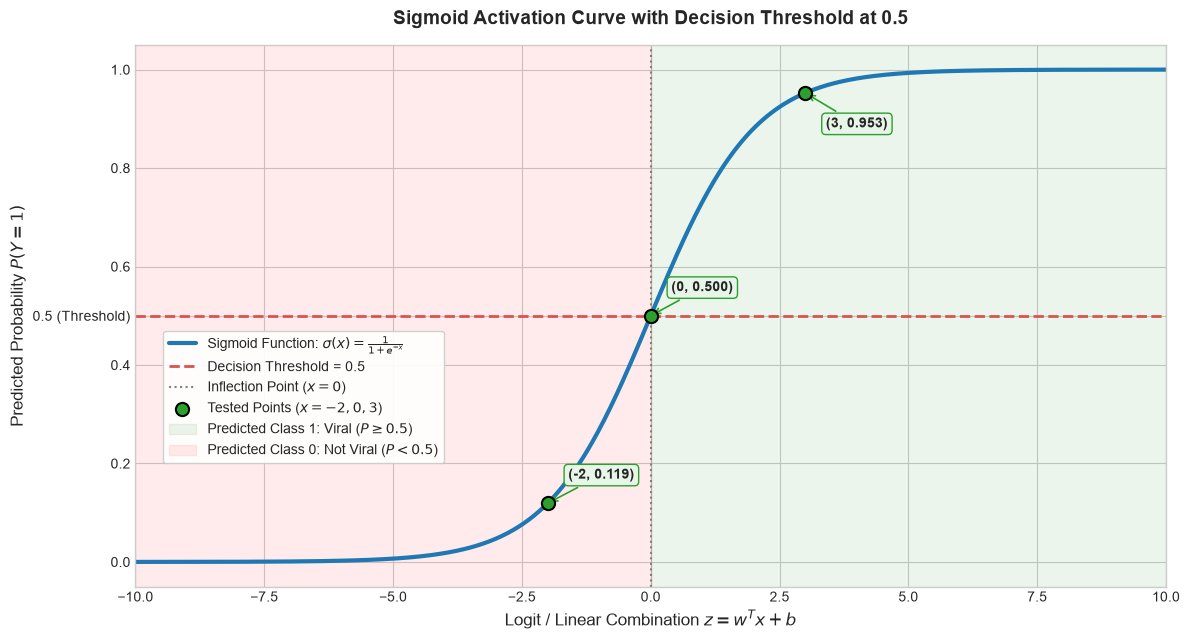

In [4]:
# Generate x values from -10 to 10
x_vals = np.linspace(-10, 10, 500)
y_vals = sigmoid(x_vals)

# Create the visualization
plt.figure(figsize=(12, 6.5))

# Plot sigmoid S-curve
plt.plot(x_vals, y_vals, color='#1f77b4', linewidth=3, label=r'Sigmoid Function: $\sigma(x) = \frac{1}{1 + e^{-x}}$')

# Indicate the 0.5 threshold line using plt.axhline()
plt.axhline(0.5, color='#d9534f', linestyle='--', linewidth=2, label='Decision Threshold = 0.5')

# Draw vertical inflection line at x = 0
plt.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Inflection Point ($x = 0$)')

# Highlight the test points from Question 1
test_pts_x = [-2, 0, 3]
test_pts_y = [sigmoid(v) for v in test_pts_x]
plt.scatter(test_pts_x, test_pts_y, color='#2ca02c', s=90, zorder=5, edgecolors='black', linewidth=1.5, label='Tested Points ($x = -2, 0, 3$)')

# Annotate each test point
for x_pt, y_pt in zip(test_pts_x, test_pts_y):
    plt.annotate(
        f"({x_pt}, {y_pt:.3f})",
        xy=(x_pt, y_pt),
        xytext=(x_pt + 0.4, y_pt - 0.07 if x_pt > 0 else y_pt + 0.05),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="#e8f5e9", ec="#2ca02c", lw=1),
        arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.2)
    )

# Shaded decision regions
plt.axvspan(0, 10, alpha=0.08, color='green', label=r'Predicted Class 1: Viral ($P \geq 0.5$)')
plt.axvspan(-10, 0, alpha=0.08, color='red', label=r'Predicted Class 0: Not Viral ($P < 0.5$)')

# Labels, title, and limits
plt.title('Sigmoid Activation Curve with Decision Threshold at 0.5', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Logit / Linear Combination $z = w^T x + b$', fontsize=12)
plt.ylabel('Predicted Probability $P(Y = 1)$', fontsize=12)
plt.xlim(-10, 10)
plt.ylim(-0.05, 1.05)
plt.yticks([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0], ['0.0', '0.2', '0.4', '0.5 (Threshold)', '0.6', '0.8', '1.0'])
plt.legend(loc='center left', bbox_to_anchor=(0.02, 0.35), frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


### Key Visual Takeaways:
- **Asymptotic Bounds**: The sigmoid function approaches $0$ as $x \to -\infty$ and approaches $1$ as $x \to +\infty$, guaranteeing all outputs are valid probabilities.
- **Threshold Symmetry**: The horizontal threshold line at $P = 0.5$ (`plt.axhline(0.5)`) intersects the curve at exactly $x = 0$.
  - When $x \ge 0$, $\sigma(x) \ge 0.5 \implies$ classified as **Viral** (Class 1).
  - When $x < 0$, $\sigma(x) < 0.5 \implies$ classified as **Not Viral** (Class 0).


## Question 4
**Given a probability output from your logistic regression model, write a function that classifies the result as `'Viral'` or `'Not Viral'` based on a threshold value that you can set (default $0.5$). Test your function with probabilities $0.2$, $0.6$, and $0.8$ and thresholds $0.5$ and $0.7$.**


In [5]:
def classify_virality(probability, threshold=0.5):
    '''
    Classify a post as 'Viral' or 'Not Viral' given its predicted probability
    and a decision threshold.
    
    Parameters:
        probability (float): Predicted probability P(Viral = 1) between 0 and 1
        threshold (float): Classification cutoff (default is 0.5)
        
    Returns:
        str: 'Viral' if probability >= threshold, else 'Not Viral'
    '''
    if not (0.0 <= probability <= 1.0):
        raise ValueError(f"Probability must be between 0.0 and 1.0. Got: {probability}")
    if not (0.0 <= threshold <= 1.0):
        raise ValueError(f"Threshold must be between 0.0 and 1.0. Got: {threshold}")
        
    if probability >= threshold:
        return 'Viral'
    else:
        return 'Not Viral'

# Test specifications:
# Probabilities: 0.2, 0.6, 0.8
# Thresholds: 0.5, 0.7
test_probs = [0.2, 0.6, 0.8]
test_thresholds = [0.5, 0.7]

classification_records = []

print("=" * 70)
print("TESTING CLASSIFICATION FUNCTION WITH PROBABILITIES & THRESHOLDS")
print("=" * 70)

for p in test_probs:
    for t in test_thresholds:
        result = classify_virality(probability=p, threshold=t)
        comparison = f"{p} >= {t}" if p >= t else f"{p} < {t}"
        classification_records.append({
            'Probability (P)': p,
            'Threshold (tau)': t,
            'Condition': comparison,
            'Classification Result': result
        })
        print(f"Prob: {p:<4} | Threshold: {t:<4} | Condition: {comparison:<9} | Result: {result}")

df_results = pd.DataFrame(classification_records)
print("-" * 70)
print("\nSummary Pivot Table:")
pivot_summary = df_results.pivot(index='Probability (P)', columns='Threshold (tau)', values='Classification Result')
print(pivot_summary)


TESTING CLASSIFICATION FUNCTION WITH PROBABILITIES & THRESHOLDS
Prob: 0.2  | Threshold: 0.5  | Condition: 0.2 < 0.5 | Result: Not Viral
Prob: 0.2  | Threshold: 0.7  | Condition: 0.2 < 0.7 | Result: Not Viral
Prob: 0.6  | Threshold: 0.5  | Condition: 0.6 >= 0.5 | Result: Viral
Prob: 0.6  | Threshold: 0.7  | Condition: 0.6 < 0.7 | Result: Not Viral
Prob: 0.8  | Threshold: 0.5  | Condition: 0.8 >= 0.5 | Result: Viral
Prob: 0.8  | Threshold: 0.7  | Condition: 0.8 >= 0.7 | Result: Viral
----------------------------------------------------------------------

Summary Pivot Table:
Threshold (tau)        0.5        0.7
Probability (P)                      
0.2              Not Viral  Not Viral
0.6                  Viral  Not Viral
0.8                  Viral      Viral


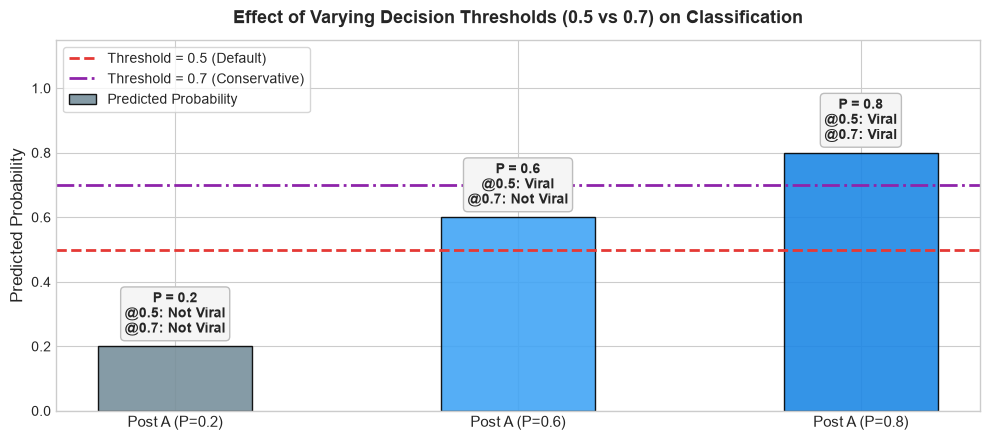

In [6]:
# Visual Comparison of Threshold Effects on Probabilities
plt.figure(figsize=(10, 4.5))

probs_demo = [0.2, 0.6, 0.8]
x_indices = np.arange(len(probs_demo))

plt.bar(x_indices, probs_demo, width=0.45, color=['#78909c', '#42a5f5', '#1e88e5'], edgecolor='black', alpha=0.9, label='Predicted Probability')

# Draw the two thresholds
plt.axhline(0.5, color='#e53935', linestyle='--', linewidth=2, label='Threshold = 0.5 (Default)')
plt.axhline(0.7, color='#8e24aa', linestyle='-.', linewidth=2, label='Threshold = 0.7 (Conservative)')

# Annotate each bar with classifications at both thresholds
for idx, p in enumerate(probs_demo):
    res_05 = classify_virality(p, threshold=0.5)
    res_07 = classify_virality(p, threshold=0.7)
    plt.text(idx, p + 0.03, f"P = {p}\n@0.5: {res_05}\n@0.7: {res_07}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec="#bdbdbd"))

plt.xticks(x_indices, [f"Post A (P={p})" for p in probs_demo], fontsize=11)
plt.ylabel('Predicted Probability', fontsize=12)
plt.ylim(0, 1.15)
plt.title('Effect of Varying Decision Thresholds (0.5 vs 0.7) on Classification', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


In [7]:
# Applying classify_virality() to the 10 Instagram posts from Question 2
print("=" * 80)
print("COMPARING THRESHOLDS ON THE 10 INSTAGRAM POSTS:")
print("=" * 80)

eval_df = df_instagram.copy()
eval_df['Model_Prob_Viral'] = np.round(log_reg.predict_proba(X)[:, 1], 4)
eval_df['Class_at_0.5'] = eval_df['Model_Prob_Viral'].apply(lambda p: classify_virality(p, threshold=0.5))
eval_df['Class_at_0.7'] = eval_df['Model_Prob_Viral'].apply(lambda p: classify_virality(p, threshold=0.7))

print(eval_df[['post_id', 'likes', 'has_caption', 'viral', 'Model_Prob_Viral', 'Class_at_0.5', 'Class_at_0.7']].to_string(index=False))


COMPARING THRESHOLDS ON THE 10 INSTAGRAM POSTS:
post_id  likes  has_caption  viral  Model_Prob_Viral Class_at_0.5 Class_at_0.7
 Post_1    120            0      0               0.0    Not Viral    Not Viral
 Post_2    450            1      0               0.0    Not Viral    Not Viral
 Post_3    850            0      0               0.0    Not Viral    Not Viral
 Post_4   1200            1      0               0.0    Not Viral    Not Viral
 Post_5   2300            0      1               1.0        Viral        Viral
 Post_6   3100            1      1               1.0        Viral        Viral
 Post_7   4200            1      1               1.0        Viral        Viral
 Post_8   5800            1      1               1.0        Viral        Viral
 Post_9   7500            0      1               1.0        Viral        Viral
Post_10   9200            1      1               1.0        Viral        Viral


### Key Insights on Threshold Tuning:
1. **Critical Comparison on $P = 0.6$**:
   - At $\tau = 0.5$: $0.6 \ge 0.5 \implies$ **`Viral`**.
   - At $\tau = 0.7$: $0.6 < 0.7 \implies$ **`Not Viral`**.
   - This directly demonstrates how adjusting the decision threshold shifts the classification of borderline instances.
2. **Precision vs. Recall Tradeoff**:
   - **Higher Threshold (e.g., $0.7$)**: Makes the model more conservative. Only posts with very high confidence ($> 70\%$) are declared 'Viral'. This increases **Precision** (fewer false positives) but lowers **Recall** (more false negatives).
   - **Lower Threshold (e.g., $0.3$ or $0.5$)**: Makes the model more aggressive in catching potential viral posts, increasing **Recall** at the expense of **Precision**.
